## Importación de librerías

In [19]:
# Importación de librerías
# -----------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Exploración de archivos
# -----------------------------------------------------------------------
import sys
sys.path.append('../')

# Configuración de Pandas
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)  # Para visualizar todas las columnas de los DataFrames

## Carga de datos

In [20]:
df = pd.read_csv('../data/dataset_estudiantes.csv')

df.head(10)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1
5,6.407690,73.089118,79.787603,8.509316,29,Difícil,No,Mañana,Visual,68.0,1
6,13.415889,91.067997,71.799792,4.589867,25,Fácil,Sí,Mañana,Visual,75.5,1
7,16.237527,96.979939,51.411965,NaN,20,Fácil,Sí,Noche,Visual,86.3,1
8,4.323579,62.103747,60.824963,6.463756,21,Medio,No,Mañana,Visual,84.8,1
9,7.928666,71.829926,100.000000,7.516230,23,Medio,Sí,Noche,Visual,68.8,1


## Análisis exploratorio

In [21]:
print(f"El número de filas que tenemos es {df.shape[0]}, y el número de columnas es {df.shape[1]}")

El número de filas que tenemos es 1000, y el número de columnas es 11


In [22]:
df.columns

Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nivel_dificultad', 'tiene_tutor',
       'horario_estudio_preferido', 'estilo_aprendizaje', 'nota_final',
       'aprobado'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   object 
 6   tiene_tutor                1000 non-null   object 
 7   horario_estudio_preferido  900 non-null    object 
 8   estilo_aprendizaje         950 non-null    object 
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 86.1+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

horas_estudio_semanal          0
nota_anterior                  0
tasa_asistencia                0
horas_sueno                  150
edad                           0
nivel_dificultad               0
tiene_tutor                    0
horario_estudio_preferido    100
estilo_aprendizaje            50
nota_final                     0
aprobado                       0
dtype: int64

### Identificación de variables numéricas y categóricas

In [24]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Variables numéricas:\n\n", num_cols)
print("\nVariables categóricas:\n\n", cat_cols)

Variables numéricas:

 Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nota_final', 'aprobado'],
      dtype='object')

Variables categóricas:

 Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje'],
      dtype='object')


## Estadísticas Descriptivas

In [9]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.07,4.85,1.0,6.63,10.00,13.37,25.0
nota_anterior,1000.0,69.89,14.69,30.0,59.88,70.00,80.12,100.0
tasa_asistencia,1000.0,73.99,18.20,20.0,61.51,75.00,88.49,100.0
horas_sueno,850.0,7.01,1.44,4.0,6.00,7.02,8.02,10.0
edad,1000.0,23.53,3.48,18.0,21.00,24.00,27.00,29.0
nota_final,1000.0,71.44,9.56,30.0,64.78,71.40,77.90,100.0
aprobado,1000.0,0.90,0.30,0.0,1.00,1.00,1.00,1.0


## Visualizaciones

### Gráficos de histogramas para variables numéricas

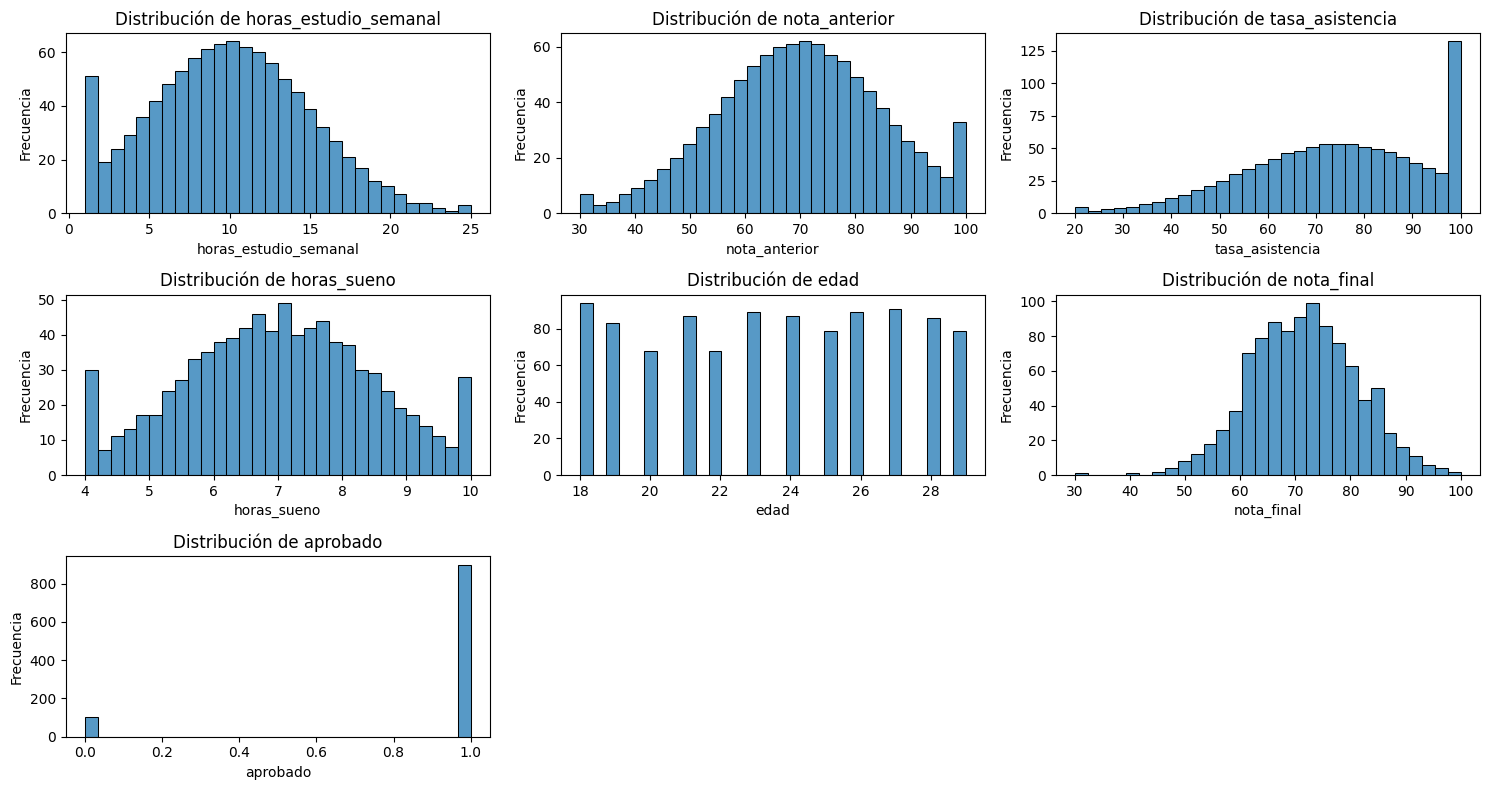

In [ ]:
ncols = 3
nrows = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 8))

# Se aplana el array de ejes para iterar más cómodamente
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=30, edgecolor='black', ax=ax)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

# Se ocultan celdas sobrantes:
for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Variables categóricas

### Estadísticas descriptivas

In [11]:
df.describe(include = "object").T

,count,unique,top,freq
nivel_dificultad,1000,3,Medio,504
tiene_tutor,1000,2,No,597
horario_estudio_preferido,900,3,Noche,344
estilo_aprendizaje,950,4,Visual,363


### Valores únicos y frecuencias

In [12]:
for col in cat_cols:
    print(f" \n----------- ESTAMOS ANALIZANDO LA COLUMNA: '{col}' -----------\n")
    print(f"Valores únicos: {df[col].unique()}\n")
    print("Frecuencias de los valores únicos de las categorías:")
    display(df[col].value_counts())

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'nivel_dificultad' -----------

Valores únicos: ['Fácil' 'Difícil' 'Medio']

Frecuencias de los valores únicos de las categorías:


nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'tiene_tutor' -----------

Valores únicos: ['Sí' 'No']

Frecuencias de los valores únicos de las categorías:


tiene_tutor
No    597
Sí    403
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'horario_estudio_preferido' -----------

Valores únicos: ['Tarde' 'Mañana' nan 'Noche']

Frecuencias de los valores únicos de las categorías:


horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'estilo_aprendizaje' -----------

Valores únicos: ['Lectura/Escritura' nan 'Visual' 'Auditivo' 'Kinestésico']

Frecuencias de los valores únicos de las categorías:


estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

## Visualizaciones

### Gráficos de barras para variables categóricas

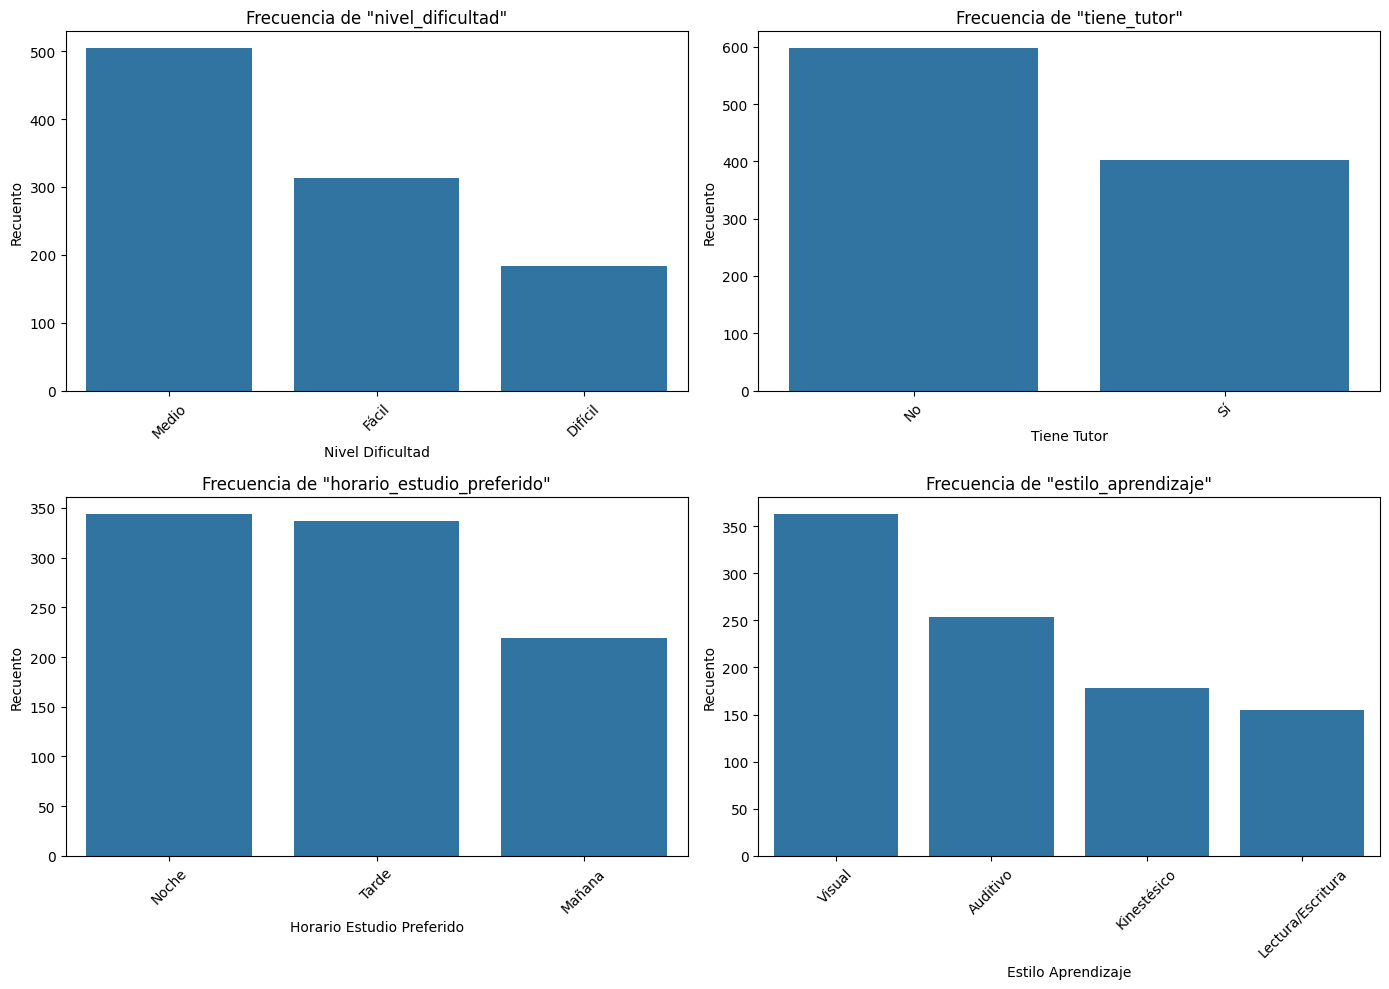

In [ ]:
# Configura subplots 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    # Se graficaa el countplot en el eje correspondiente
    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index,
        ax=ax
    )
    ax.set_title(f'Frecuencia de "{col}"')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Recuento')
    ax.tick_params(axis='x', rotation=45)

# Se oculta cualquier eje sobrante
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Matriz de correlación

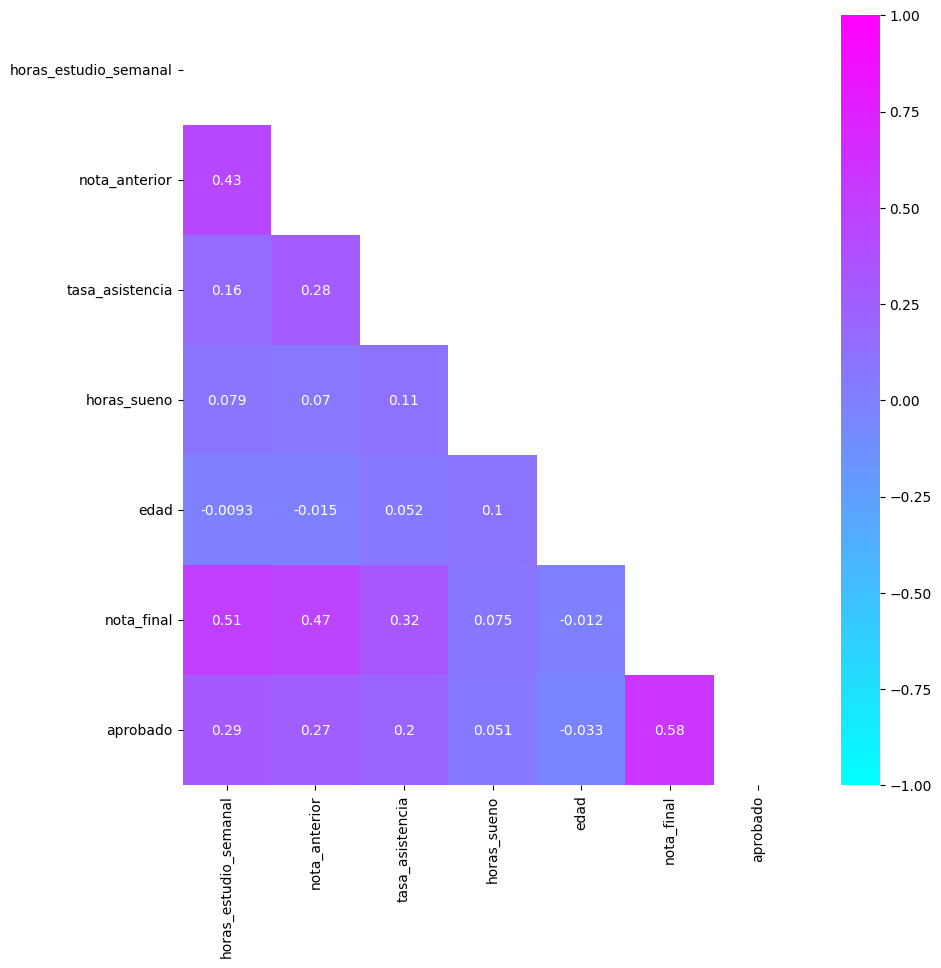

In [14]:
# Se calcula la matriz de correlación
corr_matrix = df.corr(numeric_only=True)

# Se crea la figura
plt.figure(figsize=(10, 10))

# Se crea una máscara para mostrar solo la parte triangular
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Se grafica el mapa de calor
sns.heatmap(corr_matrix, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            mask=mask,
            cmap='cool')

plt.show()

## Relaciones cruzadas

### Variable objetivo 'nota_final'

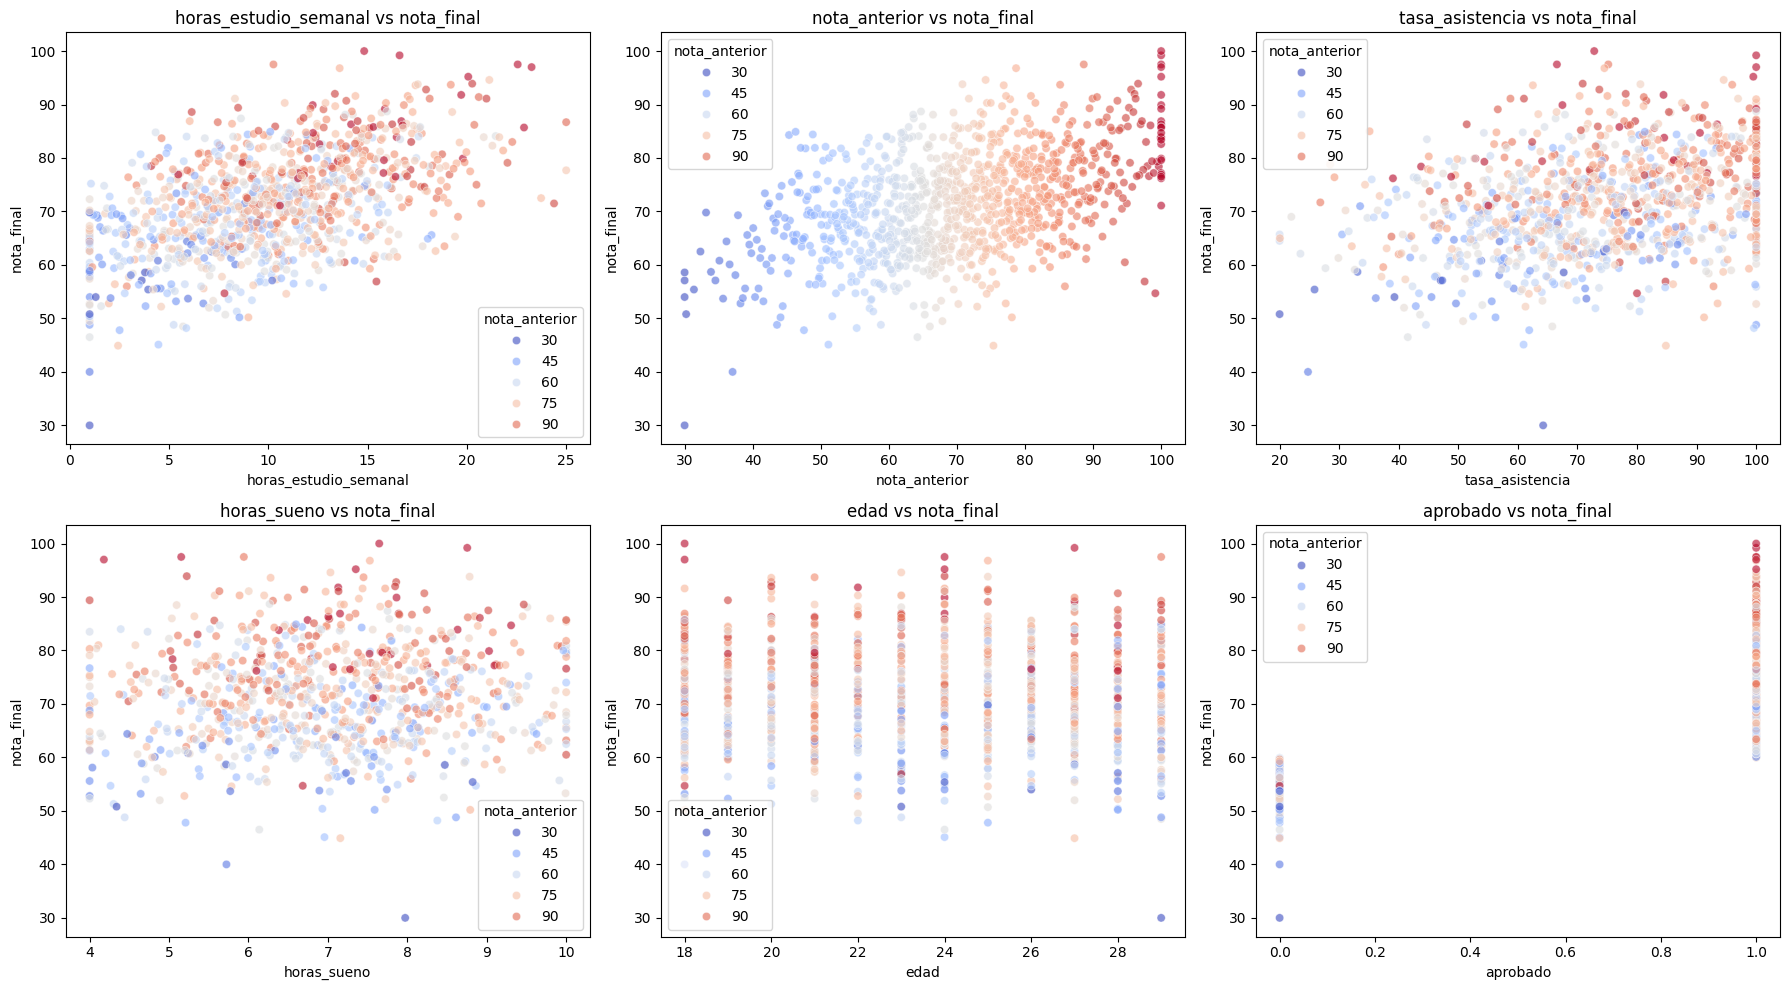

In [ ]:
# Variable objetivo
tv = 'nota_final'

# DataFrame solo con numéricas (excepto la target)
df_num = df.select_dtypes(include=np.number).drop(columns=[tv], errors='ignore')
cols_num = df_num.columns.tolist()

# Se configura la cuadrícula de subplots
n = len(cols_num)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

# Se dibuja cada scatter en su propio subplot
for ax, col in zip(axes, cols_num):
    sns.scatterplot(
        x=df[col],
        y=df[tv],
        hue=df['nota_anterior'],
        palette='coolwarm',
        alpha=0.6,
        ax=ax
    )
    ax.set_title(f'{col} vs {tv}')
    ax.set_xlabel(col)
    ax.set_ylabel(tv)

# Se oculta ejes sobrantes si los hay
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

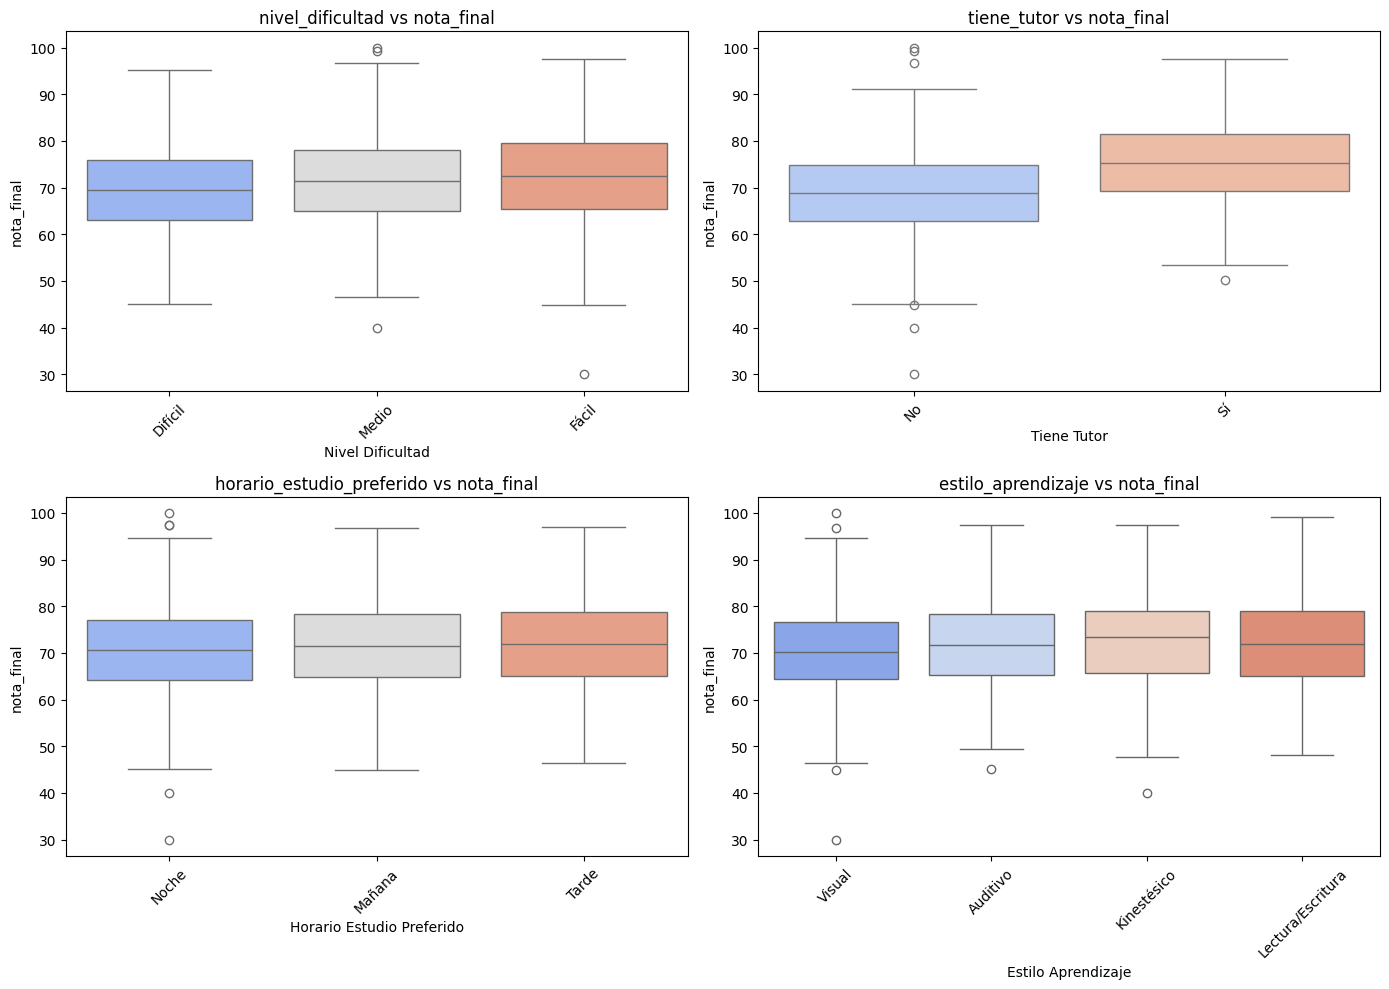

In [ ]:
# Gráfico de caja para variables categóricas vs variable objetivo
# Se prepara la cuadrícula de subplots
n = len(cat_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    # Orden de categorías según la media de la nota_final
    ordered = df.groupby(col)[tv].mean().sort_values().index
    
    sns.boxplot(
        x=col,
        y=tv,
        data=df,
        order=ordered,
        palette='coolwarm',
        ax=ax
    )
    ax.set_title(f'{col} vs {tv}')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel(tv)
    ax.tick_params(axis='x', rotation=45)

# Se oculta ejes sobrantes si hay alguno
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Variable objetivo 'aprobado'

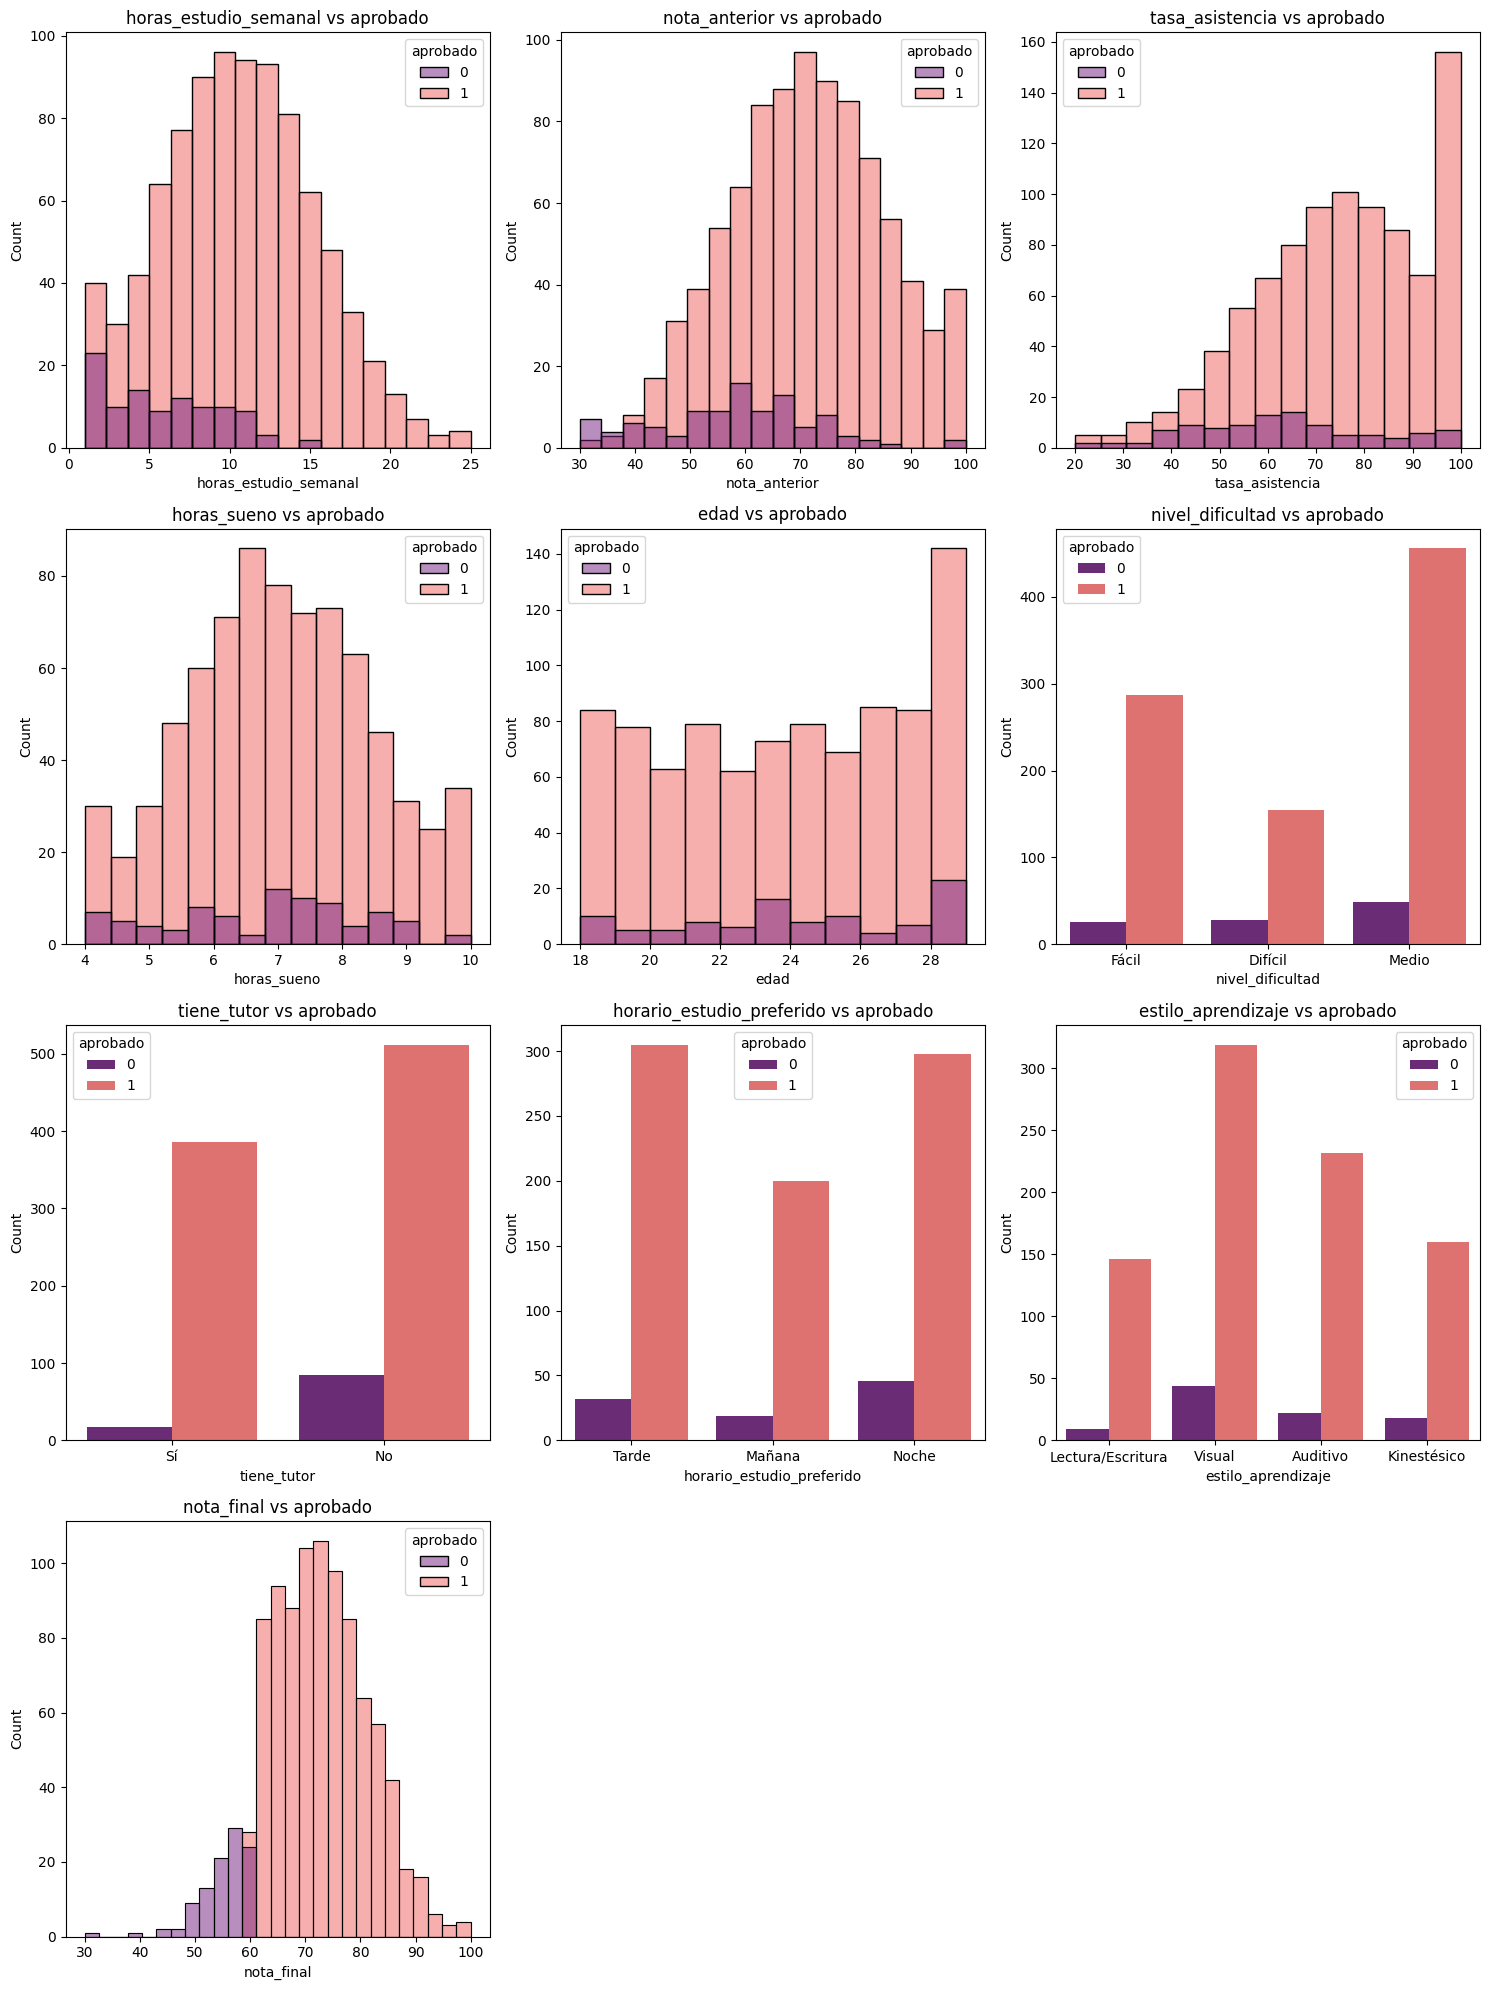

In [ ]:
# Se define la variable objetivo
tv = 'aprobado'

# Se calcula el número adecuado de filas y columnas según la cantidad de variables
n_cols = 3  # Definir el número de columnas para la cuadrícula
n_rows = (len(df.columns) - 1) // n_cols + 1  # Calcular el número de filas

# Se crea la figura y los ejes (solo los necesarios)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Se aplanan los ejes para facilitar la iteración
axes = axes.flatten()

# Contador de subgráficas usadas
used_axes = 0

# Se itera sobre las columnas de df
for i, col in enumerate(df.columns):

    # Se salta la variable objetivo
    if col == tv:
        continue

    ax = axes[used_axes]  # Se obtiene el eje correspondiente

    if col in num_cols:
        sns.histplot(x=df[col], hue=df[tv], data=df, palette="magma", legend=True, ax=ax)
    elif col in cat_cols:
        sns.countplot(x=df[col], hue=df[tv], data=df, palette="magma", ax=ax)

    ax.set_title(f"{col} vs {tv}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    # Se incrementa el contador de subgráficas usadas
    used_axes += 1

# Se ocultan los ejes sobrantes si hay más subgráficas de las que realmente se necesitan
for j in range(used_axes, len(axes)):  # Se ocultan ejes sobrantes
    axes[j].axis('off')

# Se ajusta el diseño para que no se superpongan las gráficas
plt.tight_layout()
plt.show()

### Guardado de dataframe

In [18]:
df.to_csv('../data/dataset_estudiantes_EDA.csv')